## Instal the packages

In [9]:
from numpy import mean
import pandas as pd
from numpy import std
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from matplotlib import pyplot

## Read the data

In [10]:
##Read the data
data = pd.read_csv("stack.csv")
data.head()

,Featur_1,Featur_2,Featur_3,Featur_4,Featur_5,Featur_6,Featur_7,Featur_8,Featur_9,Featur_10,...,Featur_17,Featur_18,Featur_19,Featur_20,Featur_21,Featur_22,Featur_23,Featur_24,24,Target
0,-4.213170,-2.744120,0.188518,-2.746634,-2.130921,3.957010,-4.879965,-6.819586,-0.577259,0.160943,...,-0.176326,-1.623139,-1.503584,0.685679,-4.850612,11.364803,-2.145618,-4.217774,3.514112,0
1,0.592178,5.321085,-3.604322,-2.513454,4.474060,-2.628278,-4.044510,1.577459,0.937599,-1.036958,...,3.798463,6.618811,-3.216092,8.756966,-20.912277,3.776211,0.316094,4.617879,0.879792,0
2,-0.420302,-5.727719,0.098669,1.753746,0.809984,7.182335,-1.353669,-5.902127,4.109503,0.392717,...,0.584610,-1.790268,0.762539,-0.441760,-2.531465,-0.082491,-3.346653,-1.153037,-1.306715,0
3,-4.120133,2.424011,-4.834792,-1.426744,2.135731,1.451526,-3.435943,1.758758,0.035493,-0.950379,...,-5.265885,1.124752,-3.619646,0.349428,1.794305,2.953939,-3.611214,6.721698,0.636421,1
4,0.484665,-3.056881,0.329461,-0.598967,-2.247251,0.444007,2.720293,-0.531497,-3.842148,-0.929348,...,3.537907,-1.196608,4.328183,4.003686,-5.348574,5.907073,-0.403842,-5.269747,-1.908793,1


## Identify Independent & Dependent data

In [11]:
##segregate X & y
X = data.iloc[:,:25].values
y = data.iloc[:,25].values

## Train test split

In [12]:
# train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,  y,  test_size = 0.20,  random_state = 42) 

## Stacking

In [13]:
# define the base models
level_0 = list()
level_0.append(('lr', LogisticRegression()))
level_0.append(('knn', KNeighborsClassifier()))
level_0.append(('cart', DecisionTreeClassifier()))
level_0.append(('bayes', GaussianNB()))

# define meta learner model
level_1 = LogisticRegression()

# define the stacking ensemble
model = StackingClassifier(estimators=level_0, final_estimator=level_1, cv=5)

### Evaluation

In [14]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

In [15]:
print('>%s %.3f (%.3f)' % ('stacking', mean(scores), std(scores)))

>stacking 0.940 (0.011)


## Graphical Evaluation

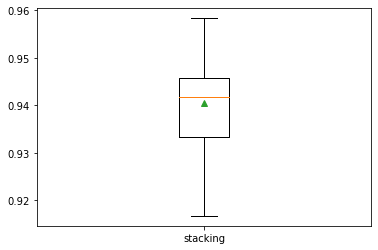

In [16]:
# plot model performance for comparison
pyplot.boxplot(scores, labels=['stacking'], showmeans=True)
pyplot.show()

## Prediction

In [17]:
# fit the model on all available data
model.fit(X_train, y_train)

# make a prediction for one example
yhat = model.predict(X_test)

## test performance

In [18]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, yhat)
print(score)

0.955


## Complete modified code

>stacking 0.945 (0.015)


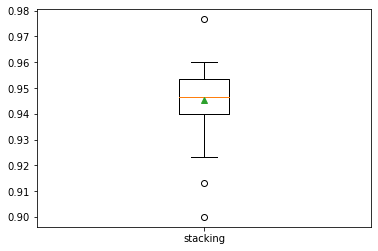

In [19]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from matplotlib import pyplot
 
# get the dataset
def get_dataset():
    ##Read the data
    data = pd.read_csv("stack.csv")
    ##segregate X & y
    X = data.iloc[:,:25].values
    y = data.iloc[:,25].values
    return X, y
 
# get a stacking ensemble of models
def get_stacking():
    # define the base models
    level_0 = list()
    level_0.append(('lr', LogisticRegression()))
    level_0.append(('knn', KNeighborsClassifier()))
    level_0.append(('cart', DecisionTreeClassifier()))
    level_0.append(('bayes', GaussianNB()))
    # define meta learner model
    level_1 = LogisticRegression()
    # define the stacking ensemble
    model = StackingClassifier(estimators=level_0, final_estimator=level_1, cv=5)
    return model
 
# get a list of models to evaluate
def get_models():
    models = dict()
    models['stacking'] = get_stacking()
    return models
 
# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
    return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
    scores = evaluate_model(model, X, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()